In [2]:
import confnotebook

In [3]:
from pathlib import Path

source = Path("../examples/test/bag_15062026")

files = sorted(source.glob("*.pdf"))

for i, file in enumerate(files):
    print(f"[{i}] {file.stem}")

[0] 000-591590 2024 Р±РЅ
[1] 000-591590 2025 Р±РЅ
[2] 000-591590 2026 Р±РЅ
[3] 04062001scan
[4] 1 квартал 2026
[5] 113130_Черно-бел. док-т_04062026
[6] 20260604scan150446
[7] 3 кв. 2025
[8] Scan_0034
[9] scan_20010116015111
[10] АС АО КУРГАНМАШЗАВОД
[11] АС РБ за 2025 г
[12] АС СУЭК апрель 26
[13] АСВ Лоста на 31.03.
[14] Акт Сверки РУСАЛ Ачинск
[15] Акт сверки 01012026-31032026
[16] Акт сверки 2025 от 16.04.2026 (1)
[17] Акт сверки 2026 от 16.04.2026
[18] Акт сверки взаиморасчетов № 05800004074 от 29 мая 2026 г
[19] Акт сверки взаиморасчетов № 102 от 03 июня 2026 г
[20] Акт сверки взаиморасчетов № 151 от 20 мая 2026 г без 9_10 этапа
[21] Акт сверки взаиморасчетов № 6171 от 02 июня 2026 г
[22] Акт сверки май 2026
[23] Акт сверки янв-мар 2026 (подпись К-ПМ)
[24] Акт сверки №1523 от 21.04.26 - 5f1bfca4-fde6-48ac-93cd-9266c8fa14d2
[25] Акт сверки №И--000238 от 06.04.26 РИТС
[26] Акт сверки
[27] Альфа-Металл
[28] БАЙКАЛ АКВА Акт сверки 2025-2026.05.28 от КП Крокус (002)
[29] Байкал Аква 23

In [4]:
IDX_FILE = 0
NUM_PAGE = 0

In [5]:
from vision_core.loader.pdf_loader import PDFLoader
from vision_core.pipelines.build_document import DocumentBuildPipeline
from vision_core.preprocessor.image_orientation import PageOrientationPreprocessor

build_pipeline = DocumentBuildPipeline()

img = PDFLoader(pdf_bytes=files[IDX_FILE].read_bytes()).get_page_image(page_num=NUM_PAGE, dpi=200)

img, _ = PageOrientationPreprocessor().process(img)
ocr_results, _ = build_pipeline._run_ocr(img)

/mnt/data/projects/rusal_recon_srv/repo/recon_vision/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `DISABLE_MODEL_SOURCE_CHECK` to `True`.
/mnt/data/projects/rusal_recon_srv/repo/recon_vision/.venv/lib/python3.11/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-OCRv5_server_det', '/mnt/data/projects/rusal_recon_srv/repo/recon_vision/models/PP-OCRv5_server_det')
Creating model: ('cyrillic_PP-OCRv5_mobile_rec', '/mnt/data/projects/rusal_recon

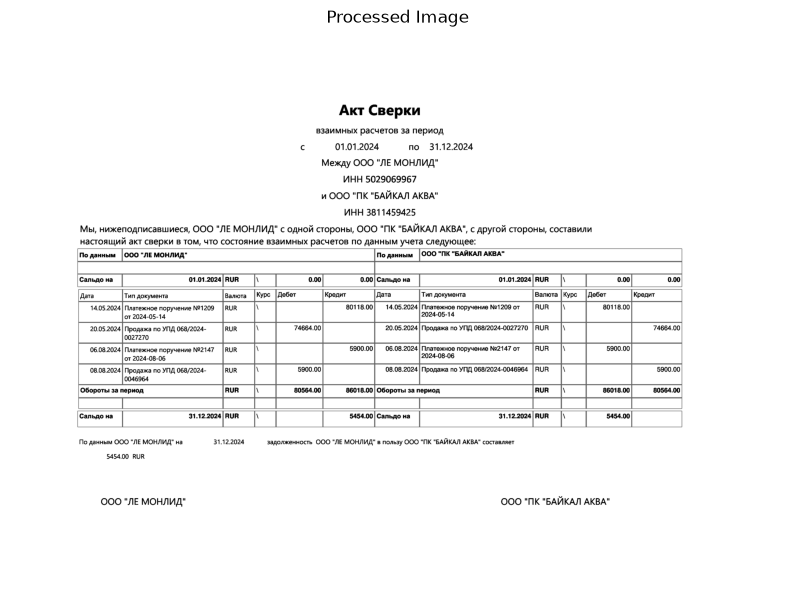

In [6]:
import cv2
import numpy as np
from matplotlib import pyplot as plt


def to_gray(img):
    if len(img.shape) == 3:
        return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        return img

def gamma_LUT(gamma=1.2):
    inv = 1.0 / gamma
    table = (np.linspace(0, 1, 256) ** inv) * 255.0
    return table.astype("uint8")


def apply_gamma(img, gamma=1.2):
    table = gamma_LUT(gamma)
    return cv2.LUT(img, table)




sharpness_img = apply_gamma(img, gamma=0.2)

cv2.imwrite(f"test_{IDX_FILE}.png", sharpness_img)

plt.figure(figsize=(10, 10))
plt.imshow(sharpness_img)
plt.title("Processed Image")
plt.axis("off")
plt.show()

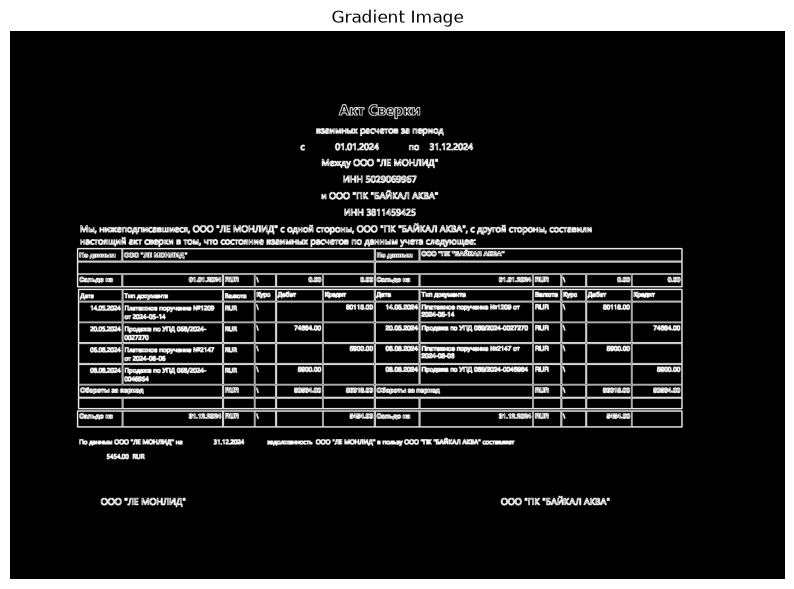

In [ ]:
import cv2

gray_img = to_gray(sharpness_img)
grad_x = cv2.Sobel(gray_img, cv2.CV_64F, 1, 0)
grad_y = cv2.Sobel(gray_img, cv2.CV_64F, 0, 1)

magnitude = cv2.magnitude(grad_x, grad_y)
sobel_edges = np.uint8(np.clip(magnitude, 0, 255))

plt.figure(figsize=(10, 10))
plt.imshow(sobel_edges, cmap='gray')
plt.title("Gradient Image")
plt.axis("off")
plt.show()

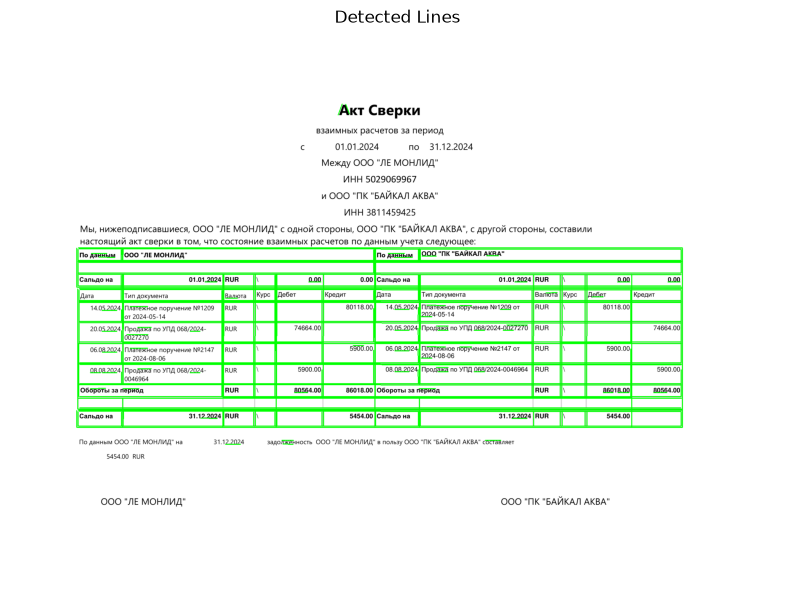

In [13]:
lines = cv2.ximgproc.createFastLineDetector(
    length_threshold=30, 
    distance_threshold=1.414, 
    canny_th1=50, canny_th2=50, canny_aperture_size=3, do_merge=True,
).detect(sobel_edges)

dbg_draw_lines = img.copy()

for line in lines:
    x1, y1, x2, y2 = line[0]
    cv2.line(dbg_draw_lines, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)


plt.figure(figsize=(10, 10))
plt.imshow(dbg_draw_lines)
plt.title("Detected Lines")
plt.axis("off")
plt.show()

In [ ]:
from dataclasses import dataclass

import cv2
import numpy as np


@dataclass(frozen=True, slots=True)
class BoundingBox:
    x_min: int
    y_min: int
    x_max: int
    y_max: int

    @property
    def width(self) -> int:
        return self.x_max - self.x_min

    @property
    def height(self) -> int:
        return self.y_max - self.y_min

    def roi(self, image: np.ndarray) -> np.ndarray:
        return image[self.y_min : self.y_max, self.x_min : self.x_max]


@dataclass(frozen=True, slots=True)
class Cell:
    bbox: BoundingBox
    row_start: int
    row_end: int
    col_start: int
    col_end: int


@dataclass(frozen=True, slots=True)
class DetectedTable:
    bbox: BoundingBox
    row_axes: tuple[int, ...]
    col_axes: tuple[int, ...]
    cells: tuple[Cell, ...]


@dataclass(slots=True)
class TableExtractorConfig:
    # Грубая маска для поиска кандидатов.
    horizontal_kernel_text_scale: float = 12.0
    coarse_vertical_kernel_text_scale: float = 4.0

    # Кандидат строится по горизонтальным осям. Соседние оси принадлежат
    # одной таблице, если между ними проходят минимум две вертикальные линии.
    candidate_min_width_ratio: float = 0.30
    candidate_axis_min_coverage: float = 0.15
    candidate_vertical_coverage: float = 0.40
    candidate_min_vertical_tracks: int = 2

    # Ограничение связи защищает от рамок/полос сканера: один длинный
    # вертикальный артефакт не должен связывать горизонтальную полосу у края
    # страницы с реальной таблицей через сотни пикселей.
    candidate_max_link_gap_row_scale: float = 4.0

    # Разорванные части одной таблицы объединяются только при малом разрыве,
    # сопоставимом с обычной высотой строки, и сильном перекрытии по X.
    candidate_merge_gap_row_scale: float = 1.40
    candidate_merge_min_x_overlap: float = 0.80

    # Неполный верхний/нижний контур может образовать отдельную группу из
    # одной-двух осей. Такую группу разрешено присоединить к соседней таблице.
    candidate_edge_fragment_max_axes: int = 2
    candidate_edge_fragment_gap_row_scale: float = 2.0
    candidate_edge_fragment_min_x_overlap: float = 0.35

    # Внутри найденного кандидата вертикальная маска строится повторно.
    # Длина ядра привязана к локальной высоте строки, а не ко всей странице.
    structure_vertical_kernel_row_scale: float = 1.0
    structure_vertical_coverage: float = 0.45
    structure_axis_min_coverage: float = 0.15

    # Вертикальная граница внутри межстрочного интервала должна иметь
    # непрерывную опору, сопоставимую с медианной высотой строки, и доходить
    # до обеих горизонтальных границ. Это отсекает вертикальные штрихи букв.
    structure_vertical_min_run_ratio: float = 0.70
    structure_vertical_anchor_text_scale: float = 0.35
    structure_vertical_gap_text_scale: float = 0.15

    boundary_presence_threshold: float = 0.35


@dataclass(slots=True)
class _CellDraft:
    row_start: int
    row_end: int
    col_start: int
    col_end: int


class TableStructureExtractor:
    """Находит табличные области и восстанавливает сетку с объединёнными ячейками."""

    def __init__(self, config: TableExtractorConfig | None = None) -> None:
        self._cfg = config or TableExtractorConfig()

    def extract(self, image: np.ndarray) -> list[DetectedTable]:
        gray = self._to_gray(image)
        text_height = self._estimate_text_height(gray)

        horizontal_mask, coarse_vertical_mask = self._extract_coarse_line_masks(
            gray,
            text_height,
        )

        # Важно: длинные вертикальные линии заранее не удаляются. Иначе одна
        # высокая таблица теряет собственные границы. Артефакт не сможет
        # склеить таблицы, потому что кандидаты разделяются по межстрочным
        # интервалам, где требуется минимум несколько вертикальных треков.
        candidates = self._detect_candidates(
            horizontal_mask,
            coarse_vertical_mask,
            text_height,
        )

        tables: list[DetectedTable] = []
        for bbox in candidates:
            table = self._extract_structure(
                gray,
                bbox,
                horizontal_mask,
                text_height,
            )
            if table is not None:
                tables.append(table)

        return sorted(tables, key=lambda table: (table.bbox.y_min, table.bbox.x_min))

    @staticmethod
    def _to_gray(image: np.ndarray) -> np.ndarray:
        if image.ndim == 2:
            return image
        if image.shape[2] == 4:
            return cv2.cvtColor(image, cv2.COLOR_BGRA2GRAY)
        return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    @staticmethod
    def _estimate_text_height(gray: np.ndarray) -> int:
        _, binary = cv2.threshold(
            gray,
            0,
            255,
            cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU,
        )
        _, _, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)

        heights = stats[1:, cv2.CC_STAT_HEIGHT]
        widths = stats[1:, cv2.CC_STAT_WIDTH]
        areas = stats[1:, cv2.CC_STAT_AREA]

        image_height, image_width = gray.shape
        valid = (
            (heights >= 3)
            & (heights <= image_height * 0.03)
            & (widths >= 1)
            & (widths <= image_width * 0.08)
            & (areas >= 4)
            & (areas <= image_height * image_width * 0.001)
        )

        if not np.any(valid):
            return max(6, round(min(gray.shape) * 0.008))

        return max(3, int(round(float(np.median(heights[valid])))))

    def _extract_coarse_line_masks(
        self,
        gray: np.ndarray,
        text_height: int,
    ) -> tuple[np.ndarray, np.ndarray]:
        binary, vertical_edges, horizontal_edges = self._extract_sources(
            gray,
            text_height,
        )

        horizontal_length = max(
            15,
            round(text_height * self._cfg.horizontal_kernel_text_scale),
        )
        vertical_length = max(
            9,
            round(text_height * self._cfg.coarse_vertical_kernel_text_scale),
        )

        horizontal_mask = self._directional_open(
            binary,
            horizontal_edges,
            (horizontal_length, 1),
        )
        vertical_mask = self._directional_open(
            binary,
            vertical_edges,
            (1, vertical_length),
        )
        return horizontal_mask, vertical_mask

    def _extract_fine_vertical_mask(
        self,
        gray_roi: np.ndarray,
        text_height: int,
        median_row_height: int,
    ) -> np.ndarray:
        binary, vertical_edges, _ = self._extract_sources(gray_roi, text_height)
        vertical_length = max(
            text_height + 2,
            round(median_row_height * self._cfg.structure_vertical_kernel_row_scale),
        )
        return self._directional_open(
            binary,
            vertical_edges,
            (1, vertical_length),
        )

    def _extract_sources(
        self,
        gray: np.ndarray,
        text_height: int,
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        block_size = self._odd(max(15, round(text_height * 3.0)))
        threshold_c = max(2, round(text_height * 1.2))

        binary = cv2.adaptiveThreshold(
            gray,
            255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV,
            block_size,
            threshold_c,
        )

        blurred = cv2.GaussianBlur(gray, (3, 3), 0)
        gradient_x = cv2.Sobel(blurred, cv2.CV_16S, 1, 0, ksize=3)
        gradient_y = cv2.Sobel(blurred, cv2.CV_16S, 0, 1, ksize=3)

        vertical_edges = self._otsu_binary(cv2.convertScaleAbs(gradient_x))
        horizontal_edges = self._otsu_binary(cv2.convertScaleAbs(gradient_y))
        return binary, vertical_edges, horizontal_edges

    @staticmethod
    def _directional_open(
        binary: np.ndarray,
        edges: np.ndarray,
        kernel_size: tuple[int, int],
    ) -> np.ndarray:
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernel_size)
        # Явный нулевой borderValue принципиален для последней строки ROI.
        # Иначе OpenCV при эрозии может сохранить короткий вертикальный штрих,
        # касающийся края изображения, хотя он короче вертикального ядра.
        morphology_kwargs = {
            "borderType": cv2.BORDER_CONSTANT,
            "borderValue": 0,
        }
        return cv2.bitwise_or(
            cv2.morphologyEx(
                edges,
                cv2.MORPH_OPEN,
                kernel,
                **morphology_kwargs,
            ),
            cv2.morphologyEx(
                binary,
                cv2.MORPH_OPEN,
                kernel,
                **morphology_kwargs,
            ),
        )

    def _detect_candidates(
        self,
        horizontal_mask: np.ndarray,
        vertical_mask: np.ndarray,
        text_height: int,
    ) -> list[BoundingBox]:
        """Группирует горизонтальные оси, не полагаясь на площадь контура.

        Связные компоненты объединённой H/V-маски для этой задачи ненадёжны:
        полоса сканера может стать самым большим компонентом, а разрыв одной
        вертикали способен разделить одну таблицу. Поэтому сначала строятся
        группы горизонтальных осей, затем локально восстанавливаются короткие
        разрывы между совместимыми группами.
        """

        cluster_gap = max(2, round(text_height * 0.20))
        row_axes = self._axis_positions(
            horizontal_mask,
            axis=1,
            min_coverage=self._cfg.candidate_axis_min_coverage,
            cluster_gap=cluster_gap,
        )
        if len(row_axes) < 3:
            return []

        spans = {
            axis: self._horizontal_axis_span(
                horizontal_mask,
                axis,
                tolerance=max(1, round(text_height * 0.15)),
            )
            for axis in row_axes
        }

        median_row_step = self._robust_axis_step(row_axes, text_height)
        max_link_gap = max(
            round(text_height * 4.0),
            round(median_row_step * self._cfg.candidate_max_link_gap_row_scale),
        )

        linked: list[bool] = []
        for y_min, y_max in zip(row_axes[:-1], row_axes[1:], strict=True):
            # Даже наличие длинной вертикальной полосы не является основанием
            # связывать оси через аномально большой пустой участок страницы.
            if y_max - y_min > max_link_gap:
                linked.append(False)
                continue

            top_span = spans[y_min]
            bottom_span = spans[y_max]
            if top_span is None or bottom_span is None:
                linked.append(False)
                continue

            x_min = max(0, min(top_span[0], bottom_span[0]) - 2 * text_height)
            x_max = min(
                horizontal_mask.shape[1] - 1,
                max(top_span[1], bottom_span[1]) + 2 * text_height,
            )
            tracks = self._vertical_tracks(
                vertical_mask,
                x_min=x_min,
                x_max=x_max,
                y_min=y_min,
                y_max=y_max,
                min_coverage=self._cfg.candidate_vertical_coverage,
                cluster_gap=max(1, round(text_height * 0.15)),
            )
            linked.append(len(tracks) >= self._cfg.candidate_min_vertical_tracks)

        groups = self._connected_axis_groups(row_axes, linked)
        groups = self._attach_edge_fragments(
            groups,
            spans,
            median_row_step,
        )
        groups = self._merge_candidate_groups(
            groups,
            spans,
            median_row_step,
        )

        image_width = horizontal_mask.shape[1]
        candidates: list[BoundingBox] = []
        for group in groups:
            if len(group) < 3:
                continue

            group_spans = [spans[axis] for axis in group if spans[axis] is not None]
            if not group_spans:
                continue

            x_min = min(span[0] for span in group_spans)
            x_max = max(span[1] for span in group_spans) + 1
            if x_max - x_min < image_width * self._cfg.candidate_min_width_ratio:
                continue

            candidates.append(
                BoundingBox(
                    x_min=int(x_min),
                    y_min=int(group[0]),
                    x_max=int(x_max),
                    y_max=int(group[-1] + 1),
                )
            )

        return candidates

    def _attach_edge_fragments(
        self,
        groups: list[list[int]],
        spans: dict[int, tuple[int, int] | None],
        median_row_step: int,
    ) -> list[list[int]]:
        """Присоединяет короткий фрагмент внешней границы к соседней группе."""

        if len(groups) < 2:
            return groups

        result = [list(group) for group in groups]
        max_gap = max(
            1,
            round(median_row_step * self._cfg.candidate_edge_fragment_gap_row_scale),
        )

        index = 0
        while index < len(result):
            group = result[index]
            if len(group) > self._cfg.candidate_edge_fragment_max_axes:
                index += 1
                continue

            attached = False
            if index + 1 < len(result):
                next_group = result[index + 1]
                gap = next_group[0] - group[-1]
                if (
                    gap <= max_gap
                    and self._groups_x_overlap(group, next_group, spans)
                    >= self._cfg.candidate_edge_fragment_min_x_overlap
                ):
                    result[index + 1] = group + next_group
                    result.pop(index)
                    attached = True

            if not attached and index > 0:
                previous_group = result[index - 1]
                gap = group[0] - previous_group[-1]
                if (
                    gap <= max_gap
                    and self._groups_x_overlap(previous_group, group, spans)
                    >= self._cfg.candidate_edge_fragment_min_x_overlap
                ):
                    result[index - 1] = previous_group + group
                    result.pop(index)
                    index -= 1
                    attached = True

            if not attached:
                index += 1

        return result

    def _merge_candidate_groups(
        self,
        groups: list[list[int]],
        spans: dict[int, tuple[int, int] | None],
        median_row_step: int,
    ) -> list[list[int]]:
        """Склеивает части одной таблицы после единичного разрыва контура."""

        if not groups:
            return []

        max_gap = max(
            1,
            round(median_row_step * self._cfg.candidate_merge_gap_row_scale),
        )
        merged: list[list[int]] = [list(groups[0])]

        for group in groups[1:]:
            previous = merged[-1]
            gap = group[0] - previous[-1]
            overlap = self._groups_x_overlap(previous, group, spans)

            if (
                len(previous) >= 3
                and len(group) >= 3
                and gap <= max_gap
                and overlap >= self._cfg.candidate_merge_min_x_overlap
            ):
                previous.extend(group)
            else:
                merged.append(list(group))

        return merged

    @staticmethod
    def _groups_x_overlap(
        first: list[int],
        second: list[int],
        spans: dict[int, tuple[int, int] | None],
    ) -> float:
        first_spans = [spans[axis] for axis in first if spans[axis] is not None]
        second_spans = [spans[axis] for axis in second if spans[axis] is not None]
        if not first_spans or not second_spans:
            return 0.0

        first_min = min(span[0] for span in first_spans)
        first_max = max(span[1] for span in first_spans)
        second_min = min(span[0] for span in second_spans)
        second_max = max(span[1] for span in second_spans)

        intersection = max(
            0,
            min(first_max, second_max) - max(first_min, second_min) + 1,
        )
        minimum_width = min(
            first_max - first_min + 1,
            second_max - second_min + 1,
        )
        return intersection / max(1, minimum_width)

    @staticmethod
    def _robust_axis_step(axes: list[int], text_height: int) -> int:
        """Оценивает обычный шаг строк без больших межтабличных разрывов."""

        if len(axes) < 2:
            return max(1, text_height)

        steps = np.diff(np.asarray(axes, dtype=np.int32))
        plausible = steps[(steps >= max(2, round(text_height * 0.5))) & (steps <= max(3, round(text_height * 6.0)))]
        if plausible.size == 0:
            plausible = steps

        return max(1, int(round(float(np.median(plausible)))))

    def _extract_structure(
        self,
        gray: np.ndarray,
        bbox: BoundingBox,
        horizontal_mask: np.ndarray,
        text_height: int,
    ) -> DetectedTable | None:
        horizontal_roi = bbox.roi(horizontal_mask)
        cluster_gap = max(2, round(text_height * 0.20))

        row_axes_local = self._axis_positions(
            horizontal_roi,
            axis=1,
            min_coverage=self._cfg.structure_axis_min_coverage,
            cluster_gap=cluster_gap,
        )
        if len(row_axes_local) < 2:
            return None

        row_steps = np.diff(row_axes_local)
        median_row_height = max(
            text_height + 2,
            int(round(float(np.median(row_steps)))),
        )

        gray_roi = bbox.roi(gray)
        vertical_roi = self._extract_fine_vertical_mask(
            gray_roi,
            text_height,
            median_row_height,
        )

        col_axes_local = self._collect_column_axes(
            vertical_roi,
            row_axes_local,
            text_height,
            median_row_height,
        )
        if len(col_axes_local) < 2:
            return None

        cells = self._build_cells(
            bbox,
            row_axes_local,
            col_axes_local,
            horizontal_roi,
            vertical_roi,
            text_height,
            median_row_height,
        )

        return DetectedTable(
            bbox=bbox,
            row_axes=tuple(bbox.y_min + value for value in row_axes_local),
            col_axes=tuple(bbox.x_min + value for value in col_axes_local),
            cells=tuple(cells),
        )

    def _collect_column_axes(
        self,
        vertical_mask: np.ndarray,
        row_axes: list[int],
        text_height: int,
        median_row_height: int,
    ) -> list[int]:
        """Собирает колонки из всех строк, включая локальные подтаблицы.

        Проекция по полной высоте кандидата здесь неприменима: вертикальная
        граница может существовать только в нескольких строках из-за merged cells.
        """

        axes: list[int] = []
        cluster_gap = max(2, round(text_height * 0.25))
        for y_min, y_max in zip(row_axes[:-1], row_axes[1:], strict=True):
            axes.extend(
                self._validated_vertical_tracks(
                    vertical_mask,
                    x_min=0,
                    x_max=vertical_mask.shape[1] - 1,
                    y_min=y_min,
                    y_max=y_max,
                    text_height=text_height,
                    median_row_height=median_row_height,
                    cluster_gap=cluster_gap,
                )
            )

        return self._cluster_values(axes, cluster_gap)

    def _validated_vertical_tracks(
        self,
        mask: np.ndarray,
        x_min: int,
        x_max: int,
        y_min: int,
        y_max: int,
        text_height: int,
        median_row_height: int,
        cluster_gap: int,
    ) -> list[int]:
        """Возвращает только вертикальные границы, соединяющие строки.

        Простая доля заполненных пикселей недостаточна: вертикальный штрих
        буквы может занять половину низкой строки. Поэтому кандидат обязан:
        1. иметь непрерывный вертикальный пробег относительно медианной
           высоты строк;
        2. подходить к верхней и нижней горизонтальным осям интервала.
        """
        if x_max <= x_min or y_max <= y_min:
            return []

        roi = mask[y_min : y_max + 1, x_min : x_max + 1]
        interval_height = roi.shape[0]
        seed_coverage = min(
            self._cfg.structure_vertical_coverage,
            self._cfg.structure_vertical_min_run_ratio * 0.5,
        )
        seed_minimum = max(1, round(interval_height * seed_coverage))
        projection = np.count_nonzero(roi, axis=0)
        positions = np.flatnonzero(projection >= seed_minimum).tolist()

        groups = self._cluster_groups(positions, cluster_gap)
        axes: list[int] = []
        tolerance = max(1, round(text_height * 0.25))

        for group in groups:
            local_x = max(group, key=lambda value: int(projection[value]))
            axis = x_min + local_x
            if self._vertical_border_present(
                mask,
                axis,
                y_min,
                y_max,
                tolerance,
                text_height,
                median_row_height,
            ):
                axes.append(axis)

        return axes

    def _vertical_border_present(
        self,
        mask: np.ndarray,
        x: int,
        y_min: int,
        y_max: int,
        tolerance: int,
        text_height: int,
        median_row_height: int,
    ) -> bool:
        x_min = max(0, x - tolerance)
        x_max = min(mask.shape[1], x + tolerance + 1)
        band = mask[y_min : y_max + 1, x_min:x_max]
        if band.size == 0:
            return False

        support = np.any(band > 0, axis=1).astype(np.uint8)
        gap_size = max(1, round(text_height * self._cfg.structure_vertical_gap_text_scale))
        if gap_size > 1:
            support = cv2.morphologyEx(
                support[:, None],
                cv2.MORPH_CLOSE,
                np.ones((gap_size, 1), dtype=np.uint8),
                borderType=cv2.BORDER_CONSTANT,
                borderValue=0,
            ).ravel()

        interval_height = support.size
        reference_height = min(interval_height, median_row_height)
        minimum_run = max(
            text_height,
            round(reference_height * self._cfg.structure_vertical_min_run_ratio),
        )
        if self._longest_true_run(support) < minimum_run:
            return False

        anchor = max(1, round(text_height * self._cfg.structure_vertical_anchor_text_scale))
        top_hit = bool(np.any(support[: min(interval_height, anchor + 1)]))
        bottom_hit = bool(np.any(support[max(0, interval_height - anchor - 1) :]))
        return top_hit and bottom_hit

    @staticmethod
    def _longest_true_run(values: np.ndarray) -> int:
        positions = np.flatnonzero(values)
        if positions.size == 0:
            return 0

        split_points = np.flatnonzero(np.diff(positions) > 1) + 1
        groups = np.split(positions, split_points)
        return max(int(group.size) for group in groups)

    @staticmethod
    def _cluster_groups(values: list[int], max_gap: int) -> list[list[int]]:
        if not values:
            return []

        sorted_values = sorted(set(int(value) for value in values))
        groups: list[list[int]] = [[sorted_values[0]]]
        for value in sorted_values[1:]:
            if value - groups[-1][-1] <= max_gap:
                groups[-1].append(value)
            else:
                groups.append([value])
        return groups

    @staticmethod
    def _connected_axis_groups(
        axes: list[int],
        linked: list[bool],
    ) -> list[list[int]]:
        groups: list[list[int]] = []
        start = 0
        for index, is_linked in enumerate(linked):
            if is_linked:
                continue
            groups.append(axes[start : index + 1])
            start = index + 1
        groups.append(axes[start:])
        return [group for group in groups if group]

    @staticmethod
    def _horizontal_axis_span(
        mask: np.ndarray,
        y: int,
        tolerance: int,
    ) -> tuple[int, int] | None:
        y_min = max(0, y - tolerance)
        y_max = min(mask.shape[0], y + tolerance + 1)
        positions = np.flatnonzero(np.any(mask[y_min:y_max] > 0, axis=0))
        if positions.size == 0:
            return None
        return int(positions[0]), int(positions[-1])

    @classmethod
    def _vertical_tracks(
        cls,
        mask: np.ndarray,
        x_min: int,
        x_max: int,
        y_min: int,
        y_max: int,
        min_coverage: float,
        cluster_gap: int,
    ) -> list[int]:
        if x_max <= x_min or y_max <= y_min:
            return []

        roi = mask[y_min : y_max + 1, x_min : x_max + 1]
        projection = np.count_nonzero(roi, axis=0)
        minimum = max(1, round(roi.shape[0] * min_coverage))
        local_positions = np.flatnonzero(projection >= minimum)
        local_axes = cls._cluster_values(local_positions.tolist(), cluster_gap)
        return [x_min + axis for axis in local_axes]

    @staticmethod
    def _cluster_values(values: list[int], max_gap: int) -> list[int]:
        if not values:
            return []

        sorted_values = sorted(set(int(value) for value in values))
        groups: list[list[int]] = [[sorted_values[0]]]
        for value in sorted_values[1:]:
            if value - groups[-1][-1] <= max_gap:
                groups[-1].append(value)
            else:
                groups.append([value])

        return [int(round(float(np.mean(group)))) for group in groups]

    def _build_cells(
        self,
        table_bbox: BoundingBox,
        row_axes: list[int],
        col_axes: list[int],
        horizontal_mask: np.ndarray,
        vertical_mask: np.ndarray,
        text_height: int,
        median_row_height: int,
    ) -> list[Cell]:
        """Строит прямоугольные ячейки построчно.

        Глобальные ``col_axes`` содержат все вертикальные границы, найденные
        хотя бы в одном участке таблицы. Поэтому сначала внутри каждой строки
        объединяются интервалы, где фактической вертикальной границы нет.
        Затем по вертикали объединяются только ячейки с одинаковым X-диапазоном.

        Такой порядок не создаёт непрямоугольных компонент на T-образных
        соединениях и не протаскивает локальные колонки в соседние секции.
        """
        num_rows = len(row_axes) - 1
        num_cols = len(col_axes) - 1
        tolerance = max(1, round(text_height * 0.25))

        row_spans: list[list[tuple[int, int]]] = []
        for row in range(num_rows):
            y_min, y_max = row_axes[row], row_axes[row + 1]
            spans: list[tuple[int, int]] = []
            col_start = 0

            for col in range(num_cols - 1):
                border_x = col_axes[col + 1]
                if self._vertical_border_present(
                    vertical_mask,
                    border_x,
                    y_min,
                    y_max,
                    tolerance,
                    text_height,
                    median_row_height,
                ):
                    spans.append((col_start, col + 1))
                    col_start = col + 1

            spans.append((col_start, num_cols))
            row_spans.append(spans)

        finished: list[_CellDraft] = []
        active: dict[tuple[int, int], _CellDraft] = {}

        for row, spans in enumerate(row_spans):
            next_active: dict[tuple[int, int], _CellDraft] = {}

            for col_start, col_end in spans:
                key = (col_start, col_end)
                draft = active.get(key)
                can_extend = False

                if draft is not None and row > 0:
                    border_y = row_axes[row]
                    x_min = col_axes[col_start]
                    x_max = col_axes[col_end]
                    score = self._horizontal_border_score(
                        horizontal_mask,
                        border_y,
                        x_min,
                        x_max,
                        tolerance,
                    )
                    can_extend = score < self._cfg.boundary_presence_threshold

                if can_extend:
                    draft.row_end = row + 1
                    next_active[key] = draft
                else:
                    next_active[key] = _CellDraft(
                        row_start=row,
                        row_end=row + 1,
                        col_start=col_start,
                        col_end=col_end,
                    )

            for key, draft in active.items():
                if next_active.get(key) is not draft:
                    finished.append(draft)

            active = next_active

        finished.extend(active.values())

        cells = [
            self._make_cell(
                table_bbox,
                row_axes,
                col_axes,
                draft.row_start,
                draft.row_end,
                draft.col_start,
                draft.col_end,
            )
            for draft in finished
        ]
        return sorted(cells, key=lambda cell: (cell.row_start, cell.col_start))

    @staticmethod
    def _make_cell(
        table_bbox: BoundingBox,
        row_axes: list[int],
        col_axes: list[int],
        row_start: int,
        row_end: int,
        col_start: int,
        col_end: int,
    ) -> Cell:
        return Cell(
            bbox=BoundingBox(
                table_bbox.x_min + col_axes[col_start],
                table_bbox.y_min + row_axes[row_start],
                table_bbox.x_min + col_axes[col_end],
                table_bbox.y_min + row_axes[row_end],
            ),
            row_start=row_start,
            row_end=row_end,
            col_start=col_start,
            col_end=col_end,
        )

    @staticmethod
    def _vertical_border_score(
        mask: np.ndarray,
        x: int,
        y_min: int,
        y_max: int,
        tolerance: int,
    ) -> float:
        x_min = max(0, x - tolerance)
        x_max = min(mask.shape[1], x + tolerance + 1)
        band = mask[y_min : y_max + 1, x_min:x_max]
        if band.size == 0:
            return 0.0
        return float(np.mean(np.any(band > 0, axis=1)))

    @staticmethod
    def _horizontal_border_score(
        mask: np.ndarray,
        y: int,
        x_min: int,
        x_max: int,
        tolerance: int,
    ) -> float:
        y_min = max(0, y - tolerance)
        y_max = min(mask.shape[0], y + tolerance + 1)
        band = mask[y_min:y_max, x_min : x_max + 1]
        if band.size == 0:
            return 0.0
        return float(np.mean(np.any(band > 0, axis=0)))

    @classmethod
    def _axis_positions(
        cls,
        mask: np.ndarray,
        axis: int,
        min_coverage: float,
        cluster_gap: int = 2,
    ) -> list[int]:
        if axis == 1:
            projection = np.count_nonzero(mask, axis=1)
            minimum = mask.shape[1] * min_coverage
        else:
            projection = np.count_nonzero(mask, axis=0)
            minimum = mask.shape[0] * min_coverage

        positions = np.flatnonzero(projection >= minimum)
        return cls._cluster_values(positions.tolist(), cluster_gap)

    @staticmethod
    def _otsu_binary(image: np.ndarray) -> np.ndarray:
        _, binary = cv2.threshold(
            image,
            0,
            255,
            cv2.THRESH_BINARY | cv2.THRESH_OTSU,
        )
        return binary

    @staticmethod
    def _odd(value: int) -> int:
        return value if value % 2 else value + 1


def draw_tables(image: np.ndarray, tables: list[DetectedTable]) -> np.ndarray:
    result = image.copy()
    for table_index, table in enumerate(tables):
        bbox = table.bbox
        cv2.rectangle(
            result,
            (bbox.x_min, bbox.y_min),
            (bbox.x_max, bbox.y_max),
            (0, 255, 0),
            2,
        )
        cv2.putText(
            result,
            f"T{table_index}",
            (bbox.x_min, max(15, bbox.y_min - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (0, 0, 255),
            2,
        )

        for cell in table.cells:
            cell_bbox = cell.bbox
            cv2.rectangle(
                result,
                (cell_bbox.x_min, cell_bbox.y_min),
                (cell_bbox.x_max, cell_bbox.y_max),
                (255, 0, 255),
                1,
            )

    return result

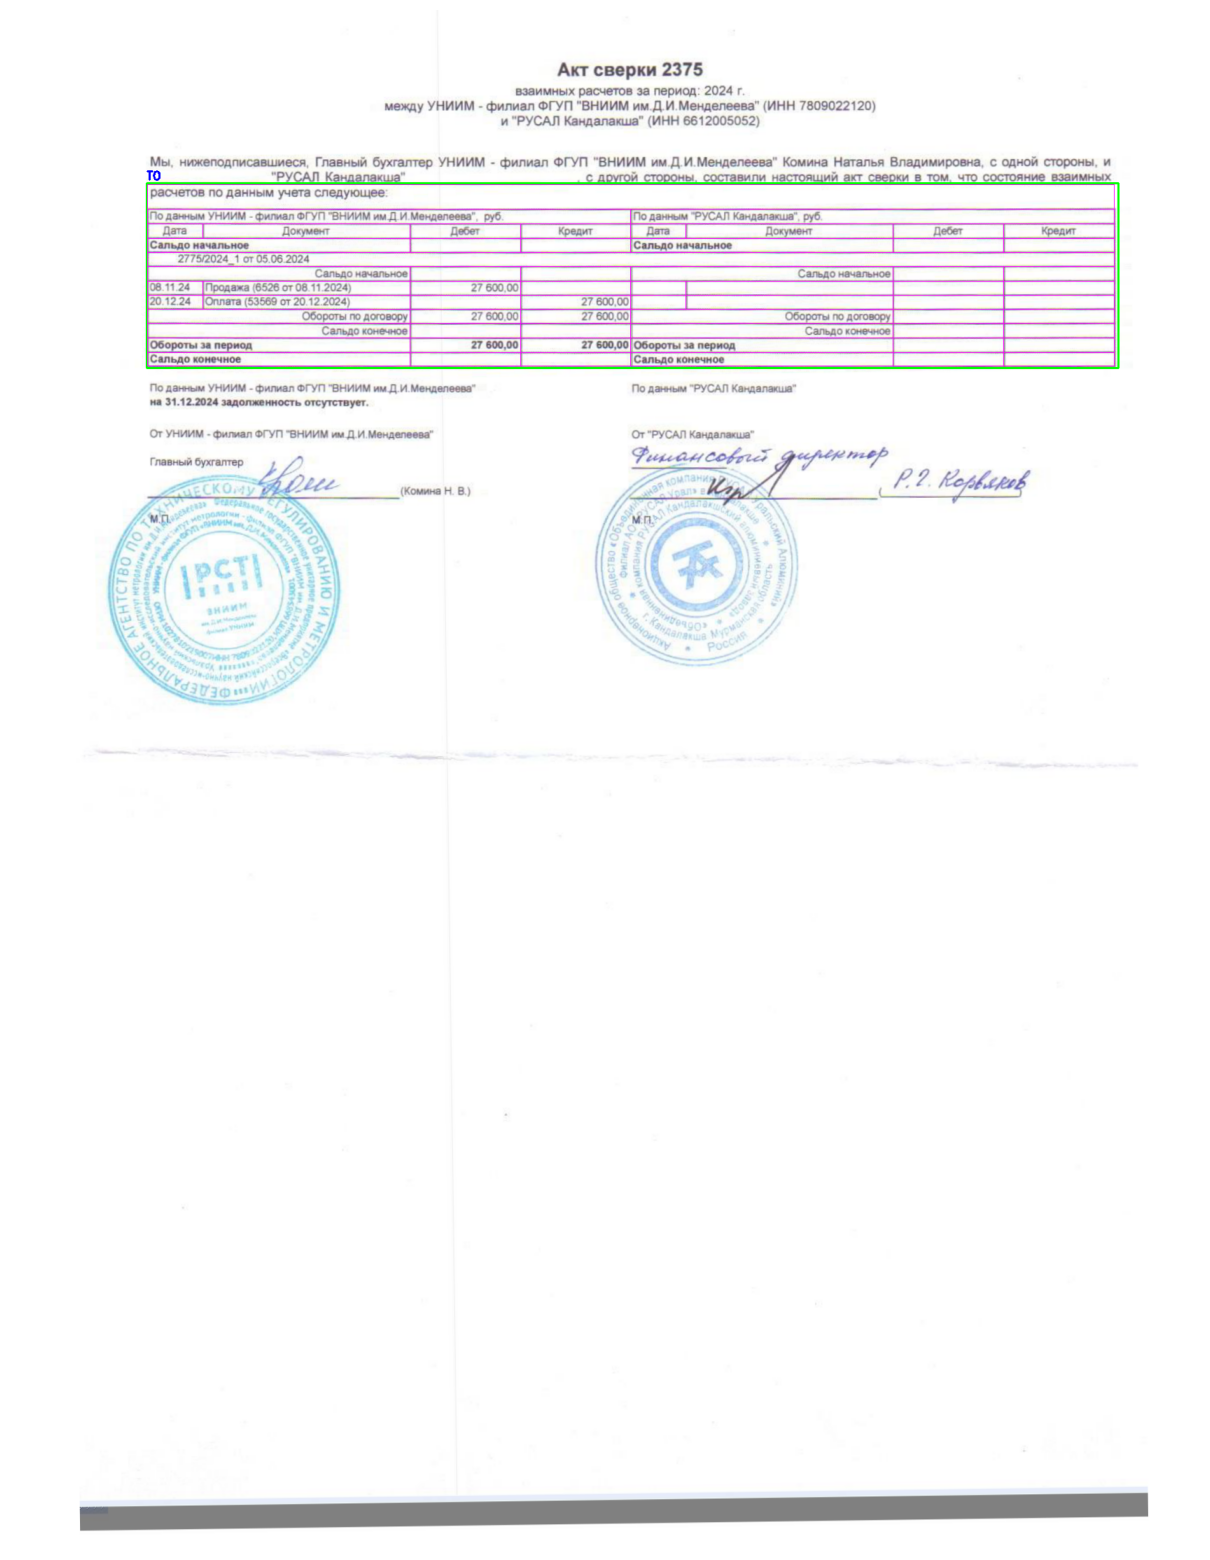

In [425]:
extractor = TableStructureExtractor()
tables = extractor.extract(lut_img)
result = draw_tables(img, tables)

plt.figure(figsize=(20, 20))
plt.imshow(result)
plt.axis("off")
plt.show()